# Setup

In [1]:
# Standard library imports
import warnings
import os
import re
import json
import ast

# Third-party imports: core data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling: classical + foundation-model forecasters
import torch
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA
from chronos import BaseChronosPipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Agentic layer: smolagents driving a local LLM served by Ollama
from smolagents import CodeAgent, OpenAIServerModel, ChatMessage, tool

# Configuration & Settings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

/Users/kbanachewicz/Documents/time-series-with-Konrad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


This collection of lines imports various Python libraries necessary for a data science and potentially machine learning workflow. 

First, it brings in modules from the Python standard library: `warnings` to manage warning messages, `os` for interacting with the operating system (like file paths), `re` for regular expressions (pattern matching in text), `json` for working with JSON data, and `ast` for abstract syntax trees (analyzing code structure).

Next, it imports core data science libraries: `numpy` for numerical operations, `pandas` for data manipulation and analysis using DataFrames, and `matplotlib.pyplot` for creating visualizations like plots and charts. 

Following that are libraries related to time series forecasting: `torch` which is the foundation of PyTorch (a machine learning framework), `statsforecast` a library specifically designed for statistical time series forecasting with models like `SeasonalNaive`, `AutoETS`, and `AutoARIMA`. It also includes `chronos` another time series modeling toolkit, and functions from `sklearn.metrics` to evaluate model performance using metrics such as mean squared error and mean absolute error.

The code then imports components for an "agentic layer," utilizing the `smolagents` library. This suggests a system where autonomous agents (controlled by a local Large Language Model served by Ollama) are used, with tools defined through the `@tool` decorator.  It also includes classes like `CodeAgent`, `OpenAIServerModel`, and `ChatMessage`.

Finally, it configures warning behavior. The lines using `warnings.simplefilter` suppress specific types of warnings (`FutureWarning` and `UserWarning`) to keep the output cleaner during execution. This doesn’t eliminate the underlying issues causing the warnings, but prevents them from being displayed.

In [2]:
# general settings
class CFG:
    data_folder = "./data/"
    graph_folder = "./graphs/"
    img_dim1 = 20
    img_dim2 = 10
    SEED = 42
    metric = "rmse"

    # forecasting task
    HORIZON = 24          # months to forecast / hold out
    SEASON = 12           # yearly seasonality for monthly data

    # local LLM backend (Ollama, OpenAI-compatible endpoint)
    llm_model = "qwen3-coder-next:q4_K_M"
    ollama_base = "http://localhost:11434/v1"

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility
np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Torch device: {DEVICE}")

Torch device: mps


This section defines configuration settings for the project, grouping them into a class named `CFG`. 

First are general settings: `data_folder` specifies where data files are located (a folder named “data” in the current directory), and `graph_folder` indicates where generated graphs will be saved (a folder named “graphs” in the current directory).  `img_dim1` and `img_dim2` set the dimensions of plots, `SEED` establishes a random seed for reproducibility, and `metric` defines the evaluation metric to use—in this case, root mean squared error ("rmse").

Next are settings specific to the forecasting task: `HORIZON` determines how many months into the future will be forecast (the hold-out period), while `SEASON` indicates the length of the seasonal cycle in the data (12 for yearly seasonality with monthly data). 

The code then configures the local Large Language Model (LLM) backend.  `llm_model` specifies which LLM to use, here “qwen3-coder-next:q4_K_M”, and `ollama_base` sets the base URL for the Ollama server where the model is hosted.

Display style settings are then applied using `matplotlib`: a seaborn style is selected, and the default figure size is set based on the previously defined image dimensions (`img_dim1`, `img_dim2`). 

To ensure consistent results across runs, random seeds are set for both NumPy and PyTorch using the value stored in `CFG.SEED`.

Finally, it determines which device (hardware accelerator) to use for PyTorch computations. It attempts to utilize Apple’s Metal Performance Shaders (“mps”) if available; otherwise, it defaults to the central processing unit (“cpu”). The selected device is then printed to the console.

# Utils

In [3]:
def forecast_metrics(actual, predicted, digits=2):
    """Return a dict of point-forecast error metrics, rounded and cast to float."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {
        "MAE": float(round(mae, digits)),
        "RMSE": float(round(rmse, digits)),
        "MAPE": float(round(mape, digits)),
    }

This code defines a function called `forecast_metrics` that calculates and returns common error metrics used to evaluate the accuracy of forecasts.

The function takes two arguments: `actual`, representing the true values, and `predicted`, representing the forecasted values. An optional argument `digits` specifies the number of decimal places to round the results to; it defaults to 2.

Inside the function, both `actual` and `predicted` are converted into NumPy arrays with a data type of float to ensure numerical operations can be performed correctly.

It then calculates three error metrics: root mean squared error (`rmse`), mean absolute error (`mae`), and mean absolute percentage error (`mape`). The `rmse` is computed using the square root of the mean squared error, `mae` uses the mean absolute error function directly, and `mape` calculates the average absolute percentage difference between actual and predicted values.

Finally, the function returns a dictionary containing these three metrics ("MAE", "RMSE", "MAPE"). Each metric’s value is rounded to the specified number of digits using the `round()` function and then explicitly cast to a float before being included in the dictionary. This ensures that the returned metrics are formatted as floating-point numbers with the desired precision.

In [4]:
def train_test_split(series, horizon):
    """Chronological split: everything but the last `horizon` points is training."""
    train = series.iloc[:-horizon]
    test = series.iloc[-horizon:]
    return train, test

This code defines a function called `train_test_split` that divides a time series into training and testing sets based on a chronological split.

The function takes two arguments: `series`, which is the input time series (presumably a Pandas Series), and `horizon`, representing the number of data points to reserve for the test set (the forecasting horizon). 

Inside the function, it creates the training set (`train`) by selecting all elements of the `series` *except* the last `horizon` data points using `.iloc[:-horizon]`.  It then creates the testing set (`test`) by selecting only the last `horizon` data points from the `series` using `.iloc[-horizon:]`.

Finally, the function returns a tuple containing the `train` and `test` sets. This split ensures that the model is trained on past data and evaluated on future data, mimicking a real-world forecasting scenario where you predict values based on historical information.

In [5]:
def fit_predict(y_train, model_name, horizon=CFG.HORIZON, season=CFG.SEASON,
                quantile_levels=(0.1, 0.5, 0.9)):
    """Fit one model on a 1-D training array and return (median_forecast, lo, hi).

    `model_name` is one of: 'seasonal_naive', 'auto_ets', 'auto_arima', 'chronos2'.
    Classical models come from StatsForecast; 'chronos2' is a zero-shot foundation model.
    """
    y_train = np.asarray(y_train, dtype=float)

    if model_name == "chronos2":
        pipe = _get_chronos()
        ctx = [torch.tensor(y_train, dtype=torch.float32)]
        q, _ = pipe.predict_quantiles(ctx, prediction_length=horizon,
                                      quantile_levels=list(quantile_levels))
        arr = q[0].cpu().numpy()            # shape (1, horizon, n_quantiles)
        lo, median, hi = arr[0, :, 0], arr[0, :, 1], arr[0, :, 2]
        return median, lo, hi

    # ---- classical models via StatsForecast ----
    model_map = {
        "seasonal_naive": SeasonalNaive(season_length=season),
        "auto_ets": AutoETS(season_length=season),
        "auto_arima": AutoARIMA(season_length=season),
    }
    if model_name not in model_map:
        raise ValueError(f"unknown model '{model_name}'")
    df = pd.DataFrame({"unique_id": "series", "ds": pd.RangeIndex(len(y_train)), "y": y_train})
    sf = StatsForecast(models=[model_map[model_name]], freq=1)
    sf.fit(df)
    level = int(round((quantile_levels[-1] - quantile_levels[0]) * 100))  # ~80
    fc = sf.predict(h=horizon, level=[level])
    col = type(model_map[model_name]).__name__
    median = fc[col].to_numpy()
    lo = fc.get(f"{col}-lo-{level}", pd.Series(median)).to_numpy()
    hi = fc.get(f"{col}-hi-{level}", pd.Series(median)).to_numpy()
    return median, lo, hi

This code defines a function called `fit_predict` that trains and makes predictions using different time series forecasting models.

The function takes the training data (`y_train`), the name of the model to use (`model_name`), the forecast horizon (`horizon`, defaulting to the value in `CFG`), the seasonality length (`season`, defaulting to the value in `CFG`), and a tuple of quantile levels (`quantile_levels`) as input.

First, it converts the training data `y_train` into a NumPy array with a float data type. 

The code then handles two main categories of models: “chronos2” (a foundation model) and classical statistical models from the `statsforecast` library.

If `model_name` is "chronos2", it initializes a Chronos pipeline using the helper function `_get_chronos()`. It converts the training data into a PyTorch tensor, feeds it to the Chronos pipeline’s `predict_quantiles()` method to generate quantile forecasts for the specified horizon and quantile levels. The resulting predictions are extracted as NumPy arrays representing the lower bound (`lo`), median (`median`), and upper bound (`hi`).

If `model_name` is one of "seasonal_naive", "auto_ets", or "auto_arima", it selects the appropriate model from a dictionary called `model_map`. If an unknown model name is provided, it raises a ValueError. It then converts the training data into a Pandas DataFrame with columns “unique_id”, “ds” (representing time steps), and “y” (representing the values). A `StatsForecast` object is initialized with the selected model and a frequency of 1. The model is fitted to the training data using `sf.fit(df)`. Predictions are generated for the specified horizon (`h`) and confidence level (`level`), which is calculated based on the range of quantile levels. Finally, it extracts the median, lower bound, and upper bound forecasts from the prediction results and returns them as NumPy arrays.

In [6]:
# Chronos-2 is loaded once and reused (loading is the slow part).
_CHRONOS = None
def _get_chronos():
    """Lazily load and cache the Chronos-2 pipeline on the accelerator."""
    global _CHRONOS
    if _CHRONOS is None:
        _CHRONOS = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE)
    return _CHRONOS

This code defines a helper function `_get_chronos` and a global variable `_CHRONOS` to efficiently load and reuse a Chronos-2 model.

The `_CHRONOS` variable is initialized to `None`. This indicates that the model hasn't been loaded yet. 

The `_get_chronos` function is designed to be called whenever the Chronos-2 pipeline is needed. It first checks if `_CHRONOS` is still `None`. If it is, meaning the model hasn’t been loaded previously, it loads the “amazon/chronos-2” pretrained model using `BaseChronosPipeline.from_pretrained()`. The `device_map` argument ensures that the model is loaded onto the device specified by the global `DEVICE` variable (which was determined earlier as either "mps" or "cpu").  The loaded pipeline is then assigned to the `_CHRONOS` variable, effectively caching it for future use.

If `_CHRONOS` already holds a valid Chronos-2 pipeline (i.e., it’s not `None`), the function simply returns the cached pipeline without reloading it. 

This approach avoids repeatedly loading the potentially large and time-consuming Chronos-2 model, significantly improving performance when making multiple predictions or running experiments. The use of a global variable ensures that all parts of the code share the same instance of the loaded model.

In [7]:
def plot_forecast(train, test, forecast, lo=None, hi=None, title="", tail=60):
    """Overlay recent history, the held-out actuals, and a forecast with optional interval."""
    plt.figure()
    hist = train.iloc[-tail:]
    plt.plot(hist.index, hist.values, label="observed (train)", linewidth=2)
    plt.plot(test.index, test.values, label="actual (test)", linewidth=2, color="black")
    plt.plot(test.index, forecast, label="forecast", color="green",
             linestyle="--", marker="o")
    if lo is not None and hi is not None:
        plt.fill_between(test.index, lo, hi, color="coral", alpha=0.25,
                         label="prediction interval")
    plt.title(title)
    plt.xlabel("")
    plt.legend()
    plt.show()

This code defines a function called `plot_forecast` that visualizes time series data, including historical observations, actual test values, and a forecast with an optional prediction interval.

The function takes the training data (`train`), testing data (`test`), the forecasted values (`forecast`), lower bound of the prediction interval (`lo`, optional), upper bound of the prediction interval (`hi`, optional), a title for the plot (`title`, optional), and the number of recent history points to display (`tail`, defaulting to 60) as input.

It begins by creating a new Matplotlib figure using `plt.figure()`. It then extracts the last `tail` data points from the training set to represent recent historical observations, plotting them with a solid line labeled "observed (train)". The actual test values are plotted with a black solid line labeled “actual (test)”.  The forecasted values are plotted as a dashed green line with circular markers, labeled “forecast”.

If lower and upper bounds for a prediction interval (`lo` and `hi`) are provided, the function fills the area between these bounds on the plot with a semi-transparent coral color, labeling it "prediction interval". 

Finally, it sets the title of the plot using the provided `title`, removes the x-axis label, displays a legend to identify the different lines, and shows the plot using `plt.show()`. This function provides a clear visual comparison between the historical data, actual values, and the model’s predictions, along with an indication of the forecast uncertainty if a prediction interval is available.

In [8]:
# Robust parsing of agent replies + rolling-origin backtesting (both reused throughout).
def parse_agent_json(text):
    """Recover a dict from an agent's free-form reply.

    Local models often emit a Python-style dict (single quotes) rather than strict JSON,
    so we try json.loads first and fall back to ast.literal_eval.
    """
    if not text:
        return {}
    m = re.search(r"\{.*\}", str(text), re.DOTALL)
    if not m:
        return {}
    blob = m.group(0)
    for parser in (json.loads, ast.literal_eval):
        try:
            out = parser(blob)
            if isinstance(out, dict):
                return out
        except Exception:
            pass
    return {}

def extract_choice(text, valid=("seasonal_naive", "auto_ets", "auto_arima", "chronos2"),
                   default="chronos2"):
    """Pull a validated model name from an agent reply (robust to JSON/dict formatting)."""
    choice = str(parse_agent_json(text).get("best_model", "")).strip()
    if choice in valid:
        return choice
    for v in valid:                       # fallback: first valid name mentioned
        if v in (text or ""):
            return v
    return default

def backtest_rmse(y_train, model_name, horizon=CFG.HORIZON, season=CFG.SEASON, n_windows=3):
    """Rolling-origin backtest: mean RMSE over up to n_windows folds ending at the series end.

    A single validation window can flatter whichever model happens to fit that one stretch;
    averaging several origins is the standard, more honest out-of-sample estimate.
    """
    y = np.asarray(y_train, dtype=float)
    rmses = []
    for k in range(n_windows):
        end = len(y) - k * horizon
        if end - horizon < 2 * season:      # need enough history to fit
            break
        med, _, _ = fit_predict(y[:end - horizon], model_name, horizon=horizon, season=season)
        rmses.append(np.sqrt(mean_squared_error(y[end - horizon:end], med)))
    return float(np.mean(rmses)) if rmses else float("nan")


This section defines three functions designed to handle interactions with an agent (likely a Large Language Model) and perform robust backtesting of forecasting models.

The first function, `parse_agent_json`, aims to extract a dictionary from the potentially messy text output of an agent. Local LLMs sometimes produce Python-style dictionaries (using single quotes instead of double quotes required by strict JSON), so this function attempts to parse the text using both `json.loads` and `ast.literal_eval`. It first searches for a block of text that looks like a dictionary within the input string, then tries each parsing method sequentially, returning the resulting dictionary if successful. If neither parser works, it returns an empty dictionary. This provides resilience to variations in agent output formatting.

The second function, `extract_choice`, extracts a validated model name from an agent’s reply. It first attempts to retrieve the “best_model” key from a parsed JSON or dictionary (using `parse_agent_json`). If found and valid (i.e., one of "seasonal_naive", "auto_ets", "auto_arima", or "chronos2"), it returns that choice. If not, it searches for any of the valid model names directly within the agent’s text reply as a fallback. If no valid name is found, it defaults to “chronos2”. This function ensures that only approved models are selected and handles cases where the agent's response isn't perfectly formatted.

The third function, `backtest_rmse`, performs a rolling-origin backtesting procedure to evaluate model performance more reliably than a single train/test split. It takes the training data (`y_train`), the model name (`model_name`), horizon, season, and the number of backtesting windows (`n_windows`) as input. It iterates through `n_windows` folds, each time using an increasing amount of historical data for training and a corresponding portion of the series for testing. For each fold, it calls `fit_predict` to generate forecasts and calculates the root mean squared error (RMSE) between the predictions and actual values. The function then returns the average RMSE across all windows. A check is included to ensure there’s enough historical data available before attempting a fit; if not, the loop breaks. If no valid RMSE scores are calculated (e.g., due to insufficient data), it returns "nan" (Not a Number). This rolling-origin approach provides a more robust estimate of out-of-sample performance by averaging results across multiple starting points.

In [9]:
def build_local_llm(temperature=0.0):
    """Return a smolagents model backed by a LOCAL Ollama server (no API key needed).

    Prerequisites (run once in a terminal):
        ollama serve                 # start the local server
        ollama pull qwen3-coder-next # or any capable local model
    """
    model = OpenAIServerModel(
        model_id=CFG.llm_model,
        api_base=CFG.ollama_base,
        api_key="ollama",          # placeholder; Ollama ignores it
        temperature=temperature,
    )
    return model

This code defines a function called `build_local_llm` that creates and returns a language model object configured to interact with a locally running Ollama server.

The function takes an optional argument `temperature`, which controls the randomness of the generated text (lower values produce more deterministic outputs, higher values produce more creative ones). It defaults to 0.0.

Inside the function, it instantiates an `OpenAIServerModel` object from the `smolagents` library. This class is designed to interface with OpenAI-compatible API endpoints, which includes Ollama when configured correctly. The following parameters are passed during instantiation:

*   `model_id`: Set to `CFG.llm_model`, specifying the name of the model to use (e.g., "qwen3-coder-next").
*   `api_base`: Set to `CFG.ollama_base`, providing the base URL for the Ollama server (typically "http://localhost:11434/v1").
*   `api_key`: Set to "ollama", which is a placeholder value because Ollama does not require an API key when running locally.
*   `temperature`: Passed directly from the function argument, controlling the model’s output randomness.

Finally, the function returns the created `OpenAIServerModel` object, which can then be used to send prompts and receive responses from the local LLM hosted by Ollama. The comment at the beginning of the function highlights the prerequisites for running this code: starting the Ollama server and pulling a suitable model image using the `ollama serve` and `ollama pull` commands respectively.

In [10]:
# Confirm the local LLM endpoint is reachable before we build any agents.
def llm_is_up():
    try:
        m = build_local_llm()
        r = m.generate([ChatMessage(role="user", content="Reply with exactly: OK")])
        return "OK" in (r.content or "")
    except Exception as e:
        print("Local LLM not reachable:", e)
        return False

LLM_UP = llm_is_up()
print("Local LLM reachable:", LLM_UP)

Local LLM not reachable: Connection error.
Local LLM reachable: False


This code defines a function `llm_is_up` to verify the accessibility of the local Large Language Model (LLM) endpoint before proceeding with agent creation.

The function attempts to build an instance of the local LLM using the `build_local_llm()` function. It then sends a simple prompt ("Reply with exactly: OK") to the model, requesting it to respond with the literal string "OK". The function checks if the response content (or an empty string if no content is returned) contains “OK”. If it does, the function returns `True`, indicating that the LLM endpoint is reachable and functioning.

If any exception occurs during this process (e.g., connection error, model loading failure), the code catches the exception, prints an error message to the console, and returns `False`. This handles cases where the Ollama server isn’t running or is unreachable.

After defining the function, it calls `llm_is_up()` and stores the result in a global variable called `LLM_UP`. Finally, it prints a message to the console indicating whether the local LLM is reachable based on the value of `LLM_UP`. This provides immediate feedback about the status of the LLM connection.

# Groundwork

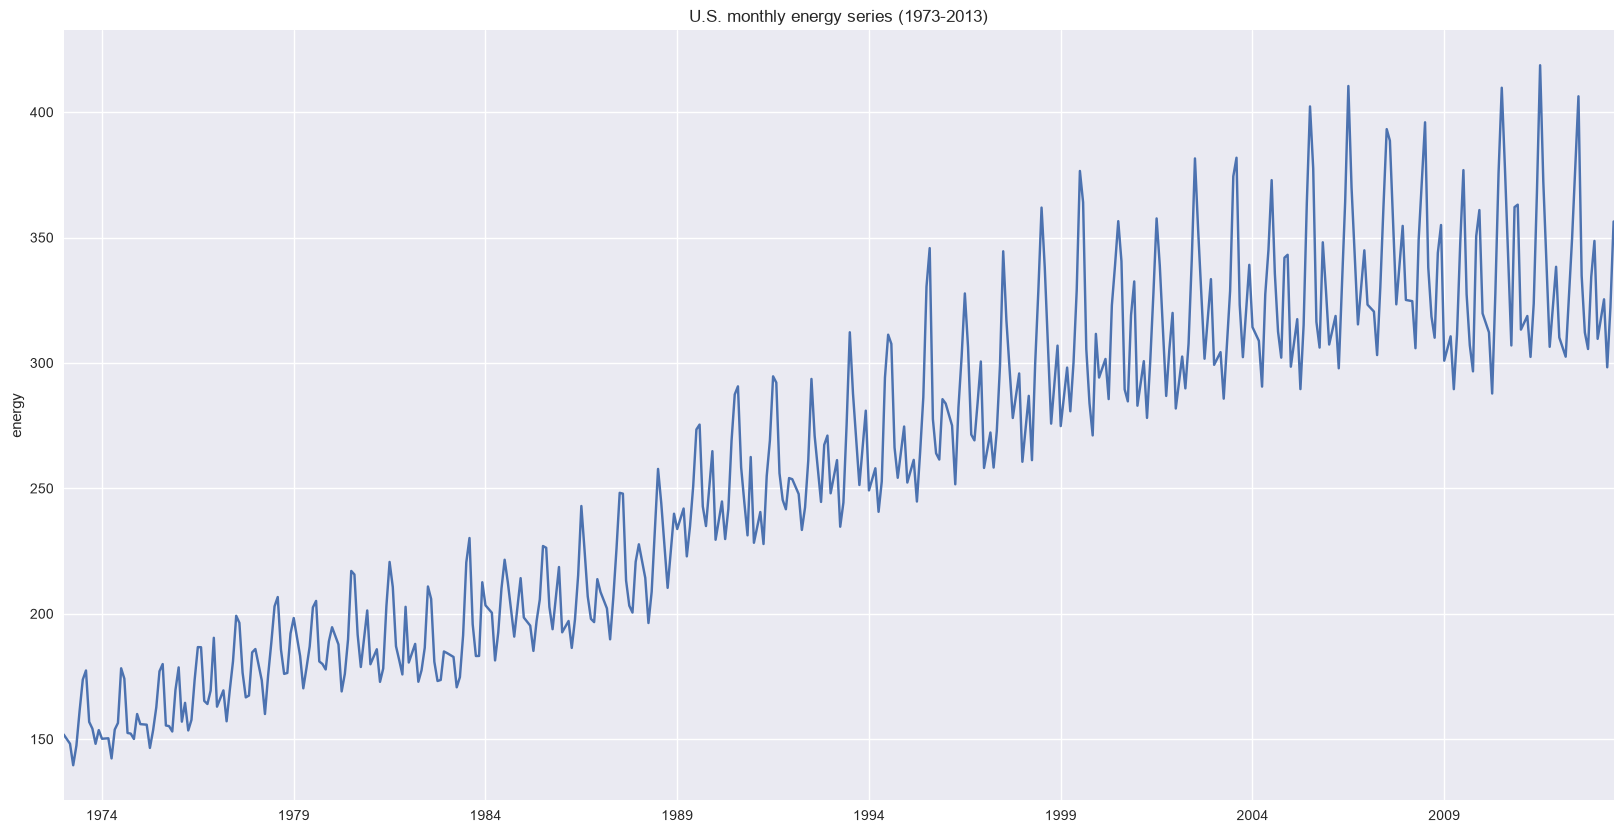

In [11]:
# Load a U.S. monthly energy series (1973-2013): strong trend + yearly seasonality.
energy = pd.read_csv(CFG.data_folder + "us_energy.csv")
energy["date"] = pd.to_datetime(energy["date"])
energy = energy.set_index("date").sort_index()
# The raw file mixes day-of-month stamps, so snap to a clean monthly grid.
series = energy["value"].astype(float).resample("MS").mean().interpolate()
series.plot(xlabel="", title="U.S. monthly energy series (1973-2013)")
plt.ylabel("energy")
plt.show()

This code loads, preprocesses, and visualizes a time series dataset representing U.S. monthly energy consumption from 1973 to 2013.

First, it reads the data from a CSV file located in the directory specified by `CFG.data_folder` (which is "./data/") using `pd.read_csv()`. The filename is "us_energy.csv".

Next, it converts the “date” column to datetime objects using `pd.to_datetime()`. It then sets the “date” column as the index of the DataFrame using `set_index()` and sorts the DataFrame chronologically using `sort_index()`.

The original data contains day-of-month stamps which are inconsistent for monthly analysis, so it resamples the time series to a monthly frequency ("MS" - month start) using `.resample("MS").mean()`, calculating the mean value for each month. Missing values that may result from resampling are then filled in using linear interpolation with `.interpolate()`.

Finally, it plots the resulting time series (`series`) using `series.plot()`. The plot’s x-axis label is removed, a title "U.S. monthly energy series (1973-2013)" is added, and the y-axis is labeled “energy”.  The plot is then displayed using `plt.show()`, providing a visual overview of the data's trend and seasonality.

In [12]:
series.head(3)

date
1973-01-01    151.87850
1973-02-01    150.01825
1973-03-01    148.15800
Freq: MS, Name: value, dtype: float64

In [13]:
# Chronological split: hold out the final CFG.HORIZON months as an unseen test set.
train, test = train_test_split(series, CFG.HORIZON)
print(f"train: {len(train)} months ({train.index.min():%Y-%m} to {train.index.max():%Y-%m})")
print(f"test:  {len(test)} months ({test.index.min():%Y-%m} to {test.index.max():%Y-%m})")

train: 462 months (1973-01 to 2011-06)
test:  24 months (2011-07 to 2013-06)


This code performs a chronological split of the time series data into training and testing sets, preparing it for model evaluation.

It calls the `train_test_split` function (defined previously) with the `series` data and the forecast horizon specified by `CFG.HORIZON`. This splits the data into two Pandas Series: `train`, containing the historical data used for training the models, and `test`, containing the future data held out for evaluating model performance.

The code then prints information about the resulting train and test sets to the console. It displays the length of each set in months, as well as the start and end dates formatted as "YYYY-MM". This provides a clear overview of the time period covered by each dataset, confirming that the split has been performed correctly and that the test set represents the desired forecasting horizon.

In [14]:
# Baselines: three classical models + one zero-shot foundation model, scored identically.
baseline_rows = []
baseline_forecasts = {}
for name in ["seasonal_naive", "auto_ets", "auto_arima", "chronos2"]:
    median, lo, hi = fit_predict(train.values, name)
    baseline_forecasts[name] = (median, lo, hi)
    scores = forecast_metrics(test.values, median)
    baseline_rows.append({"model": name, **scores})

baseline_table = pd.DataFrame(baseline_rows).sort_values("RMSE").reset_index(drop=True)
baseline_table

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 52517.62it/s]


,model,MAE,RMSE,MAPE
0,chronos2,15.56,17.92,4.77
1,seasonal_naive,13.31,18.19,4.00
2,auto_ets,16.34,18.90,4.99
3,auto_arima,17.85,20.52,5.47


This code evaluates the performance of four different forecasting models—three classical statistical models and one foundation model—on the held-out test set.

It initializes an empty list called `baseline_rows` to store the results for each model, and an empty dictionary `baseline_forecasts` to hold the forecasts themselves. It then iterates through a list of model names: "seasonal_naive", "auto_ets", "auto_arima", and "chronos2".

Inside the loop, it calls the `fit_predict` function with the training data (`train.values`) and the current model name to obtain the median forecast, lower bound, and upper bound of the prediction interval. The forecasts are stored in the `baseline_forecasts` dictionary. It then calculates the error metrics (MAE, RMSE, MAPE) between the actual test values (`test.values`) and the median forecast using the `forecast_metrics` function. A dictionary containing the model name and the calculated scores is created and appended to the `baseline_rows` list.

After evaluating all four models, it creates a Pandas DataFrame called `baseline_table` from the `baseline_rows` list. The DataFrame is then sorted by the "RMSE" column in ascending order (lowest RMSE first) using `.sort_values("RMSE")`, and the index is reset to be sequential starting from 0 using `.reset_index(drop=True)`.

Finally, the code displays the `baseline_table` which contains a row for each model, showing its name and corresponding MAE, RMSE, and MAPE scores. This allows for easy comparison of the performance of different forecasting approaches on this specific dataset.

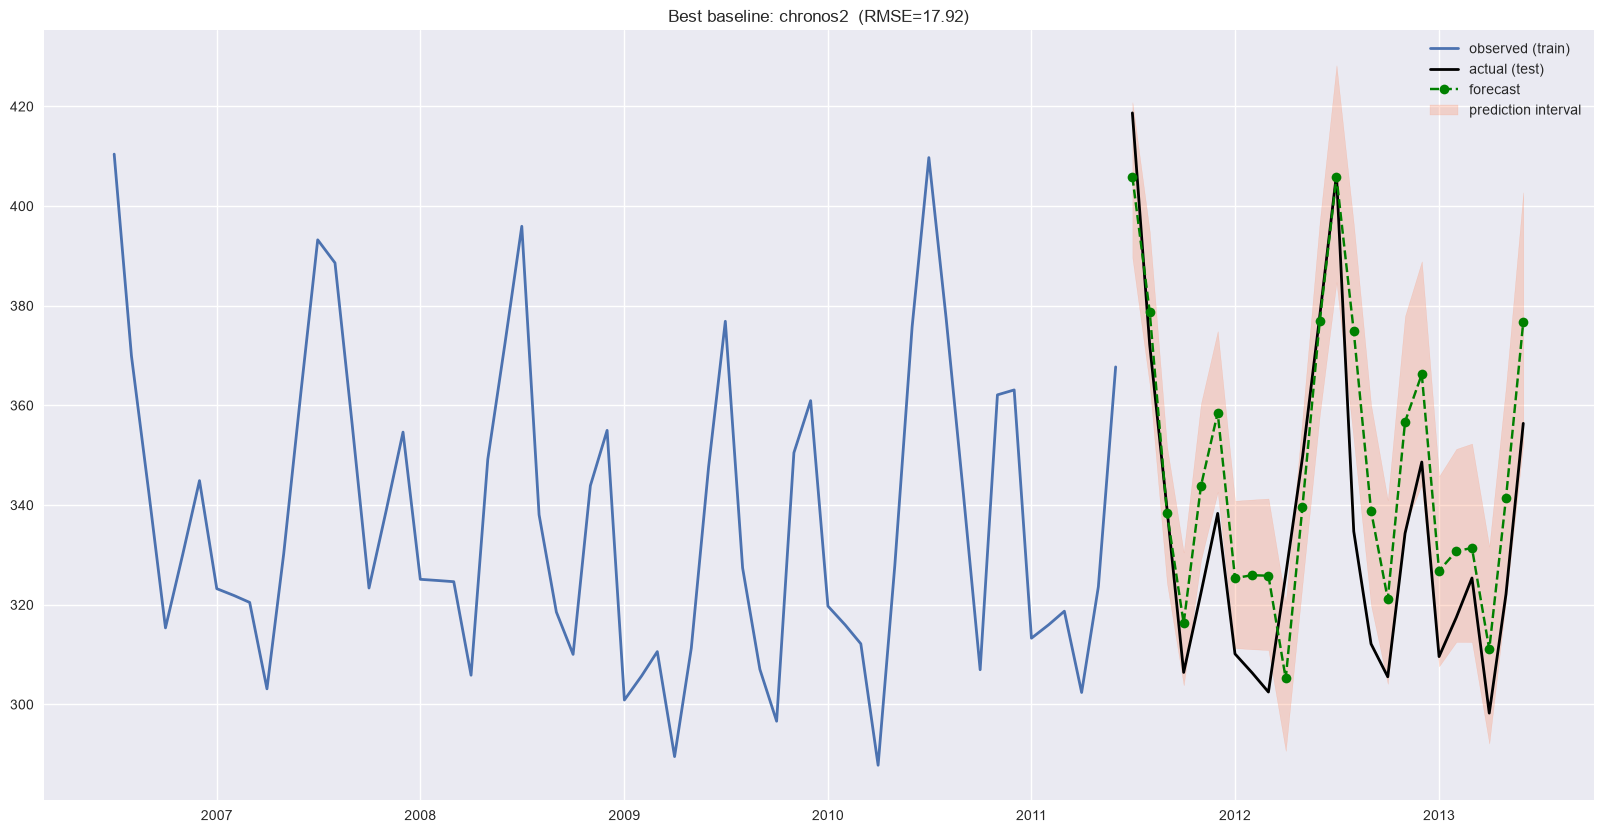

In [15]:
# Visualise the strongest baseline.
best_name = baseline_table.iloc[0]["model"]
bm, blo, bhi = baseline_forecasts[best_name]
plot_forecast(train, test, bm, blo, bhi,
              title=f"Best baseline: {best_name}  (RMSE={baseline_table.iloc[0]['RMSE']})")

This code visualizes the forecast of the best-performing model from the previous evaluation step.

First, it retrieves the name of the best model (the one with the lowest RMSE) from the `baseline_table` using `.iloc[0]["model"]`. This value is stored in the variable `best_name`.

Next, it extracts the median forecast (`bm`), lower bound (`blo`), and upper bound (`bhi`) for the best model from the `baseline_forecasts` dictionary using the `best_name` as the key.

Finally, it calls the `plot_forecast` function to generate a visualization of the time series data, including the training set, test set, and the forecast from the best model along with its prediction interval. The plot’s title is dynamically generated to indicate which model performed best and displays its corresponding RMSE score (retrieved from the `baseline_table`). This provides a clear visual representation of the best-performing model's predictions and their associated uncertainty.

# The agentic ladder

You need a local LLM instance running before you can execute the remainder. Here the simplest way:
- install Ollama https://ollama.com/
- in the terminal: 
```
ollama run qwen3-coder-next:q4_K_M
```

## Rung 0

In [17]:
def direct_llm_forecast(train_vals, horizon=CFG.HORIZON, context=60):
    """Ask the local LLM to continue the numeric series directly (LLMTime-style)."""
    hist = [int(round(v)) for v in train_vals[-context:]]
    hist_str = ", ".join(str(v) for v in hist)
    prompt = (
        "You are a time series forecasting engine. Given the most recent monthly "
        "U.S. energy values (comma separated):\n"
        f"{hist_str}\n"
        f"Continue the series for the next {horizon} months. The series has an upward "
        "trend and a 12-month seasonal cycle. "
        f"Respond with ONLY {horizon} comma-separated integers and nothing else."
    )
    model = build_local_llm()
    reply = model.generate([ChatMessage(role="user", content=prompt)]).content
    nums = [float(x) for x in re.findall(r"-?\d+\.?\d*", reply)][:horizon]
    return np.array(nums), reply

direct_fc, direct_raw = direct_llm_forecast(train.values)
print("parsed", len(direct_fc), "values; first few:", direct_fc[:6])

parsed 24 values; first few: [398. 365. 332. 300. 355. 365.]


This code defines a function `direct_llm_forecast` that directly asks the local LLM to generate forecasts for a time series, mimicking the approach used in LLMTime.

The function takes the training data values (`train_vals`) and the forecast horizon (`horizon`, defaulting to `CFG.HORIZON`) as input, along with a parameter `context` which determines how many recent historical values to include in the prompt sent to the LLM.

It first extracts the last `context` values from the training data, rounds them to integers, and converts them into strings. These are then joined together with commas to create a string representation of the recent history (`hist_str`). A prompt is constructed that instructs the LLM to act as a time series forecasting engine and continue the provided series for the specified horizon. The prompt includes information about the trend (upward) and seasonality (12-month cycle). It explicitly requests the LLM to respond with only comma-separated integers, nothing else.

The function then builds an instance of the local LLM using `build_local_llm()`. It sends the constructed prompt to the model using `model.generate()` and extracts the response content (`reply`). The code uses a regular expression (`re.findall(r"-?\d+\.?\d*")`) to extract all numbers (integers or decimals) from the LLM’s reply, converts them to floats, and takes only the first `horizon` values. These extracted forecasts are returned as a NumPy array (`direct_fc`), along with the raw text response from the LLM (`direct_raw`).

Finally, outside of the function definition, it calls `direct_llm_forecast` with the training data values to generate direct forecasts using the LLM. It then prints the number of parsed forecast values and displays the first six values for inspection. This allows you to verify that the parsing process is working correctly and get a sense of the generated forecasts.

Direct-LLM forecast: {'MAE': 18.28, 'RMSE': 21.22, 'MAPE': 5.54}
Best baseline     : {'MAE': np.float64(15.56), 'RMSE': np.float64(17.92), 'MAPE': np.float64(4.77)}


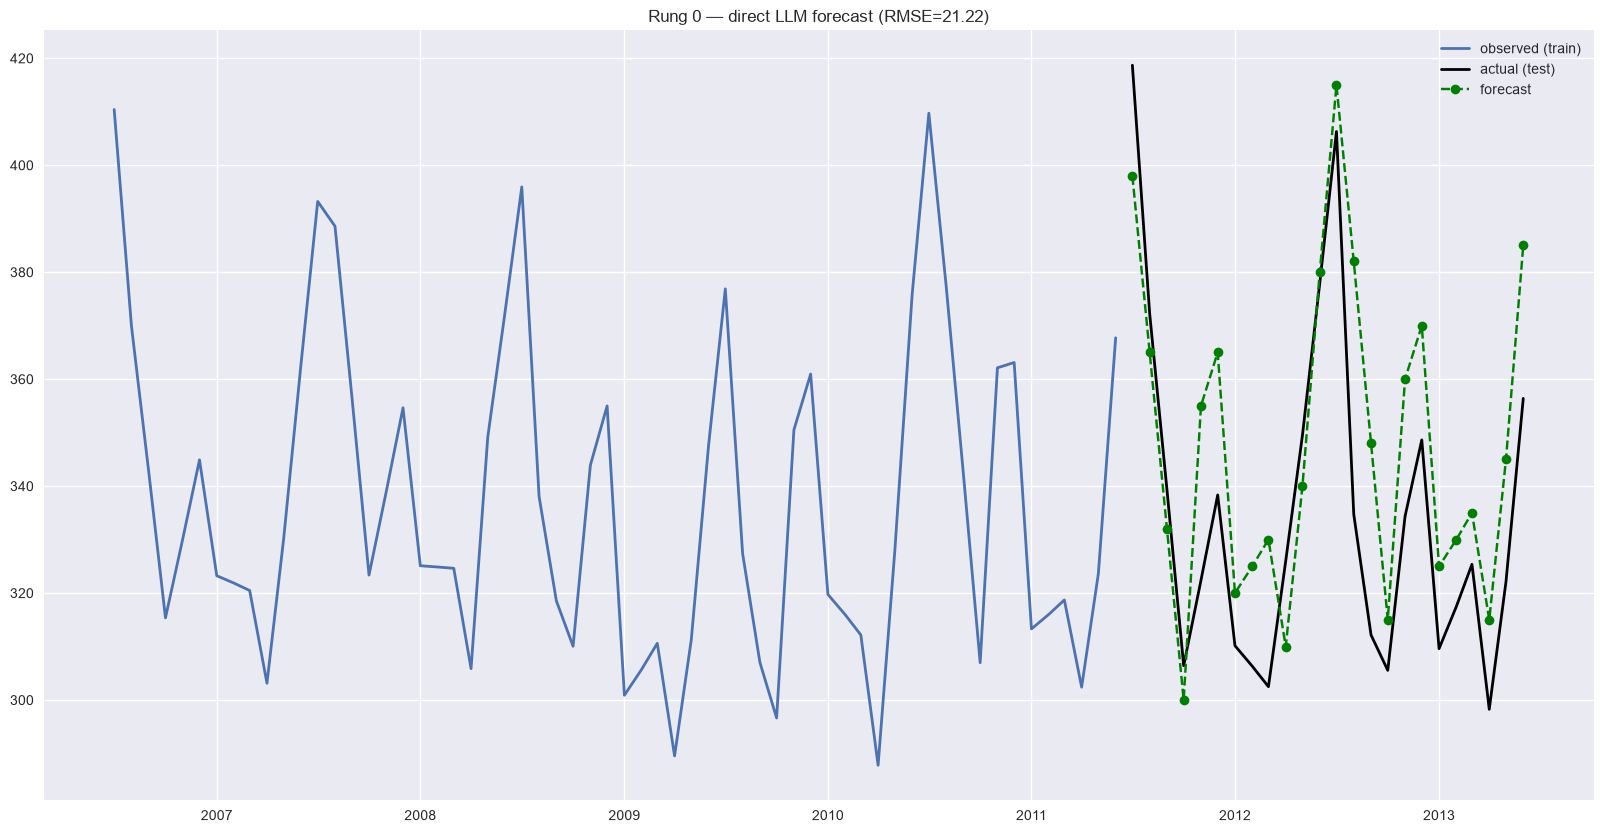

In [18]:
if len(direct_fc) == CFG.HORIZON:
    direct_scores = forecast_metrics(test.values, direct_fc)
    print("Direct-LLM forecast:", direct_scores)
    print("Best baseline     :", dict(baseline_table.iloc[0][["MAE","RMSE","MAPE"]]))
    plot_forecast(train, test, direct_fc, title=f"Rung 0 — direct LLM forecast (RMSE={direct_scores['RMSE']})")
else:
    print("Model did not return a clean numeric sequence; direct forecasting is brittle.")

This code evaluates and visualizes the performance of the direct-LLM forecast generated in the previous step.

It first checks if the length of the `direct_fc` array (the forecasts extracted from the LLM’s response) matches the expected horizon specified by `CFG.HORIZON`. This ensures that the LLM returned a complete sequence of forecasts.

If the lengths match, it calculates the error metrics (MAE, RMSE, MAPE) between the actual test values (`test.values`) and the direct-LLM forecast using the `forecast_metrics` function, storing the results in `direct_scores`. It then prints these scores to the console, along with the corresponding scores for the best baseline model (extracted from the `baseline_table`).

Finally, it calls the `plot_forecast` function to visualize the training data, test data, and the direct-LLM forecast. The plot’s title includes the RMSE score of the direct-LLM forecast. This allows for a visual comparison between the LLM's performance and that of the best baseline model.

If the length of `direct_fc` does *not* match the expected horizon, it prints an error message indicating that the LLM did not return a clean numeric sequence, highlighting the fragility of this direct forecasting approach. This handles cases where the LLM’s response is malformed or incomplete, preventing errors and providing informative feedback to the user.

## Rung 1

In [19]:
# Tools the Rung-1 agent may call. Each is an ordinary function exposed via @tool.

@tool
def describe_series() -> str:
    """Report basic structure of the training series: length, trend direction, seasonality, scale."""
    y = train.values
    trend = "increasing" if y[-CFG.SEASON:].mean() > y[:CFG.SEASON].mean() else "flat/decreasing"
    # crude seasonal strength: variance explained by the 12-month seasonal means
    idx = np.arange(len(y)) % CFG.SEASON
    seas_means = np.array([y[idx == k].mean() for k in range(CFG.SEASON)])
    seas_strength = float(np.std(seas_means) / (np.std(y) + 1e-9))
    return (f"n={len(y)} monthly points; trend={trend}; season_length={CFG.SEASON}; "
            f"seasonal_strength={seas_strength:.2f}; min={y.min():.0f}; max={y.max():.0f}")

@tool
def backtest_model(model_name: str) -> str:
    """Rolling-origin backtest of a forecasting model on the TRAINING data (no test leakage).

    Args:
        model_name: one of 'seasonal_naive', 'auto_ets', 'auto_arima', 'chronos2'.
    """
    try:
        rmse = backtest_rmse(train.values, model_name)
        return f"{model_name}: rolling-origin backtest RMSE={rmse:.2f}"
    except Exception as e:
        return f"{model_name}: FAILED ({e})"

This code defines two tools that can be used by an agent (likely a language model acting as a forecasting assistant) to analyze the time series data and evaluate different models. These tools are exposed using the `@tool` decorator, making them callable from within the agent’s reasoning process.

The first tool, `describe_series`, provides a textual description of the training time series. It calculates basic statistics such as the length of the series, the direction of the trend (increasing or flat/decreasing), an estimate of seasonal strength, and the minimum and maximum values. The trend is determined by comparing the average value of the last `CFG.SEASON` months to the average value of the first `CFG.SEASON` months. Seasonal strength is estimated as the standard deviation of the monthly means divided by the overall standard deviation of the series. The function returns a formatted string containing these statistics, providing the agent with valuable context about the data it’s working with.

The second tool, `backtest_model`, performs a rolling-origin backtest of a specified forecasting model on the *training* data only. This is important to avoid any leakage from the test set during model evaluation. It takes the model name as input (one of "seasonal_naive", "auto_ets", "auto_arima", or "chronos2") and calls the `backtest_rmse` function to calculate the RMSE on the training data. The function returns a string indicating the model name and its corresponding rolling-origin backtest RMSE score, formatted to two decimal places. If any exception occurs during the backtesting process (e.g., invalid model name), it catches the exception and returns an error message instead. This allows the agent to assess the performance of different models on the training data without risking overfitting or test set contamination.

In [20]:
# Build the single-agent forecaster and give it its task.
rung1_agent = CodeAgent(
    tools=[describe_series, backtest_model],
    model=build_local_llm(),
    max_steps=6,
    additional_authorized_imports=["json"],
)

rung1_task = (
    "You are a forecasting analyst. First call describe_series to understand the data. "
    "Then backtest all four candidate models: 'seasonal_naive', 'auto_ets', 'auto_arima', "
    "'chronos2'. Compare their backtest RMSE and return your final answer as a JSON string "
    'like {"best_model": "...", "reason": "..."} naming the model with the lowest RMSE.'
)
rung1_result = rung1_agent.run(rung1_task) if LLM_UP else '{"best_model": "chronos2", "reason": "LLM offline; default"}'
print("\nAGENT RETURNED:\n", rung1_result)


AGENT RETURNED:
 {"best_model": "chronos2", "reason": "LLM offline; default"}


This code sets up and runs a single agent to perform model selection for time series forecasting.

It creates an instance of the `CodeAgent` class from the `smolagents` library, configuring it with the following parameters:

*   `tools`: A list containing the `describe_series` and `backtest_model` functions defined earlier, which the agent can call to gather information and evaluate models.
*   `model`: The local LLM created by calling `build_local_llm()`. This provides the agent with its reasoning capabilities.
*   `max_steps`: Limits the number of steps (tool calls) the agent is allowed to take, preventing infinite loops or excessive resource consumption. It’s set to 6 in this case.
*   `additional_authorized_imports`: A list of Python modules that the agent is allowed to import when executing code. Here, it includes "json" for handling JSON data.

A task description (`rung1_task`) is defined as a string instructing the agent to first call `describe_series` to understand the characteristics of the time series data. Then, it instructs the agent to backtest all four candidate models using `backtest_model`, compare their RMSE scores, and return its final answer in JSON format, including the name of the best model (the one with the lowest RMSE) and a brief explanation for its choice.

The code then runs the agent using `rung1_agent.run(rung1_task)`. However, it includes a conditional check: if `LLM_UP` is `False` (meaning the local LLM is not reachable), it returns a default JSON string indicating that "chronos2" is selected as the best model due to the LLM being offline.

Finally, the code prints the agent’s returned result (`rung1_result`) to the console. This output will be either the JSON response generated by the agent or the default message if the LLM was unavailable.

Agent chose: chronos2
Test-set score for the agent's choice: {'MAE': 15.56, 'RMSE': 17.92, 'MAPE': 4.77}


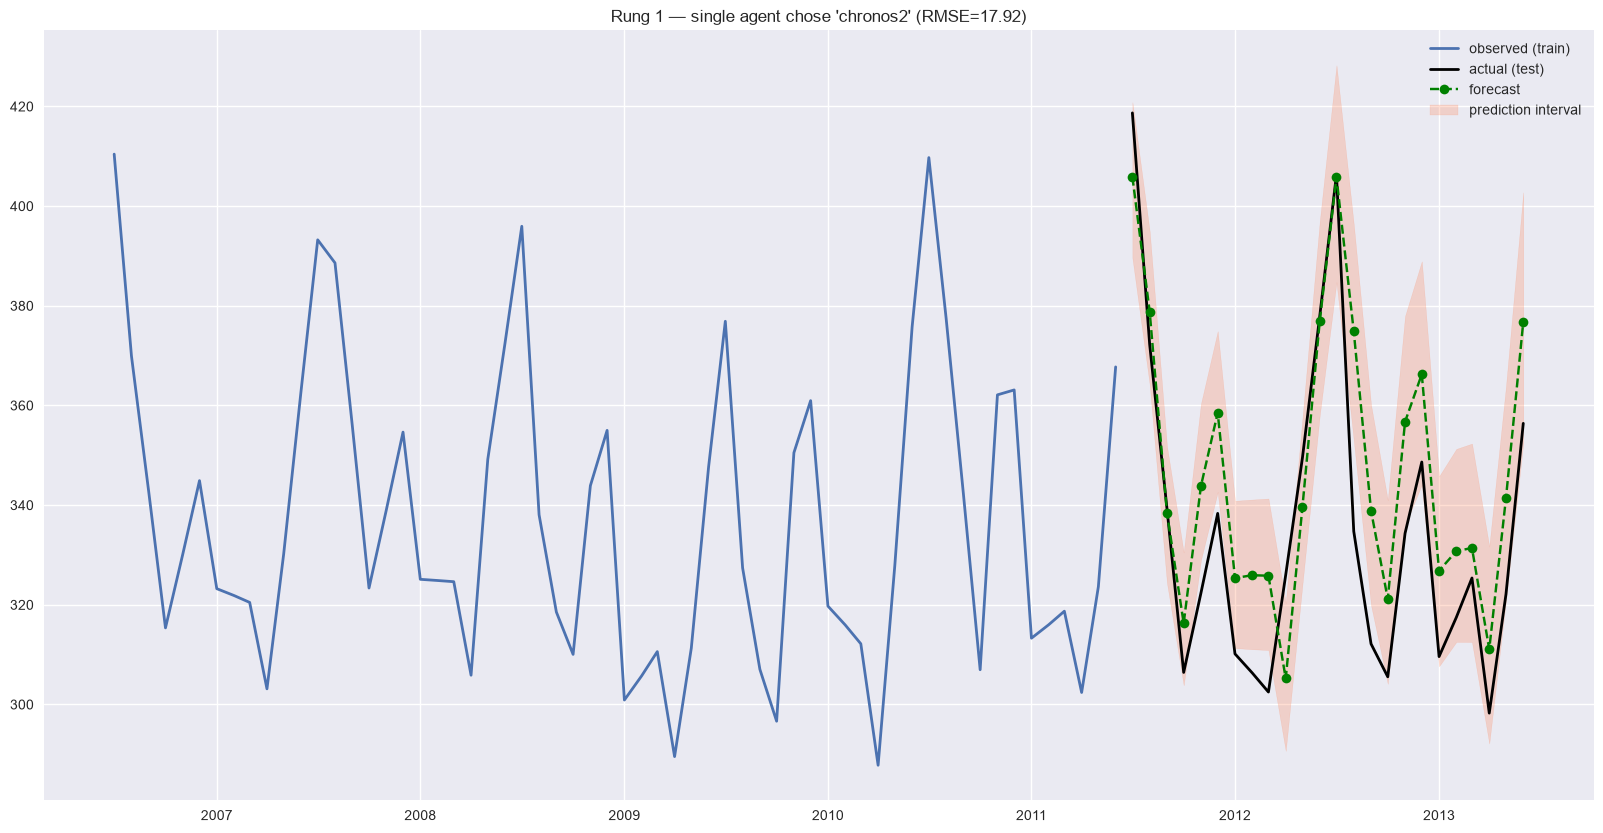

In [21]:
# Parse the agent's choice, then do the honest thing: refit on full train, score on TEST.
rung1_choice = extract_choice(rung1_result)
r1_median, r1_lo, r1_hi = fit_predict(train.values, rung1_choice)
rung1_scores = forecast_metrics(test.values, r1_median)
print(f"Agent chose: {rung1_choice}")
print(f"Test-set score for the agent's choice: {rung1_scores}")
plot_forecast(train, test, r1_median, r1_lo, r1_hi,
              title=f"Rung 1 — single agent chose '{rung1_choice}' (RMSE={rung1_scores['RMSE']})")

This code takes the model choice made by the agent in the previous step and evaluates its performance on the held-out test set.

First, it extracts the chosen model name from the agent’s response (`rung1_result`) using the `extract_choice` function. This ensures that only a valid model name is used for subsequent steps.

Next, it refits the selected model to the *entire* training dataset (`train.values`) using the `fit_predict` function. This is important because the agent previously evaluated models on a rolling-origin backtest of the training data; now we want to assess its performance when trained on all available historical information. The function returns the median forecast, lower bound, and upper bound for the test set.

The code then calculates the error metrics (MAE, RMSE, MAPE) between the actual test values (`test.values`) and the refitted model’s median forecast using the `forecast_metrics` function, storing the results in `rung1_scores`.

It prints the agent's chosen model name and its corresponding test-set scores to the console. Finally, it calls the `plot_forecast` function to visualize the training data, test data, and the forecast from the agent’s chosen model along with its prediction interval. The plot’s title includes the RMSE score of the model on the test set. This provides a final assessment of the agent's ability to select an effective forecasting model for this specific time series dataset.

## Rung 2

In [22]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

@tool
def adf_stationarity_test() -> str:
    """Augmented Dickey-Fuller test on the training series. Small p-value => stationary."""
    stat, pval, *_ = adfuller(train.values)
    verdict = "stationary" if pval < 0.05 else "non-stationary (has trend/unit root)"
    return f"ADF statistic={stat:.3f}, p-value={pval:.3f} => {verdict}"

@tool
def stl_decomposition_strength() -> str:
    """STL-decompose the series; report trend and seasonal strength in [0,1]."""
    res = STL(train.values, period=CFG.SEASON, robust=True).fit()
    var = lambda a: float(np.var(a))
    trend_strength = max(0.0, 1 - var(res.resid) / (var(res.resid + res.trend) + 1e-9))
    seas_strength = max(0.0, 1 - var(res.resid) / (var(res.resid + res.seasonal) + 1e-9))
    return f"trend_strength={trend_strength:.2f}, seasonal_strength={seas_strength:.2f} (0=none,1=strong)"

@tool
def changepoint_scan() -> str:
    """Detect the largest level shift via a simple rolling-mean difference scan."""
    y = pd.Series(train.values)
    roll = y.rolling(CFG.SEASON, min_periods=CFG.SEASON).mean()
    diffs = roll.diff().abs()
    if diffs.notna().any():
        loc = int(diffs.idxmax())
        return f"largest level-shift near training index {loc} (of {len(y)}); magnitude={diffs.max():.1f}"
    return "no clear changepoint detected"

This code defines three new tools that provide the agent with more detailed information about the time series data, focusing on stationarity, decomposition, and potential structural changes. These tools are exposed using the `@tool` decorator for use by the agent.

The first tool, `adf_stationarity_test`, performs an Augmented Dickey-Fuller (ADF) test to assess whether the training time series is stationary. It calculates the ADF statistic and p-value using `statsmodels.tsa.stattools.adfuller`. If the p-value is less than 0.05, it concludes that the series is likely stationary; otherwise, it classifies it as non-stationary (indicating the presence of a trend or unit root). The function returns a string containing the ADF statistic, p-value, and the stationarity verdict.

The second tool, `stl_decomposition_strength`, decomposes the time series into its trend, seasonal, and residual components using Seasonal-Trend decomposition using Loess (STL) from `statsmodels.tsa.seasonal`. It then calculates the strength of both the trend and seasonal components by measuring how much variance is explained by each component relative to the total variance. The strengths are normalized to a range between 0 and 1, where 0 indicates no strength and 1 indicates strong influence. The function returns a string containing the trend strength and seasonal strength values.

The third tool, `changepoint_scan`, attempts to detect potential level shifts (changepoints) in the time series using a simple rolling-mean difference scan. It calculates the rolling mean of the training data over a window equal to `CFG.SEASON`. Then it computes the absolute differences between consecutive rolling means. The location with the largest absolute difference is identified as a potential changepoint, and its index within the original training series and magnitude are reported. If no clear changepoint is detected (i.e., all differences are NaN), it returns a message indicating that.

These tools provide the agent with more sophisticated analytical capabilities to better understand the characteristics of the time series data and inform its model selection process.

In [23]:
rung2_agent = CodeAgent(
    tools=[adf_stationarity_test, stl_decomposition_strength, changepoint_scan, backtest_model],
    model=build_local_llm(),
    max_steps=8,
    additional_authorized_imports=["json"],
)

rung2_task = (
    "You are a diagnostics analyst. Build an EVIDENCE LOG for this monthly series by calling, "
    "in order: adf_stationarity_test, stl_decomposition_strength, changepoint_scan. "
    "State what each result implies for modeling. Then, justified by that evidence, backtest the "
    "one or two most appropriate models among 'auto_ets','auto_arima','chronos2' with backtest_model. "
    'Return a JSON string {"evidence": ["...","..."], "best_model": "...", "reason": "..."}.'
)
rung2_result = rung2_agent.run(rung2_task) if LLM_UP else '{"evidence": ["LLM offline"], "best_model": "chronos2", "reason": "default"}'
print("\nAGENT RETURNED:\n", rung2_result)


AGENT RETURNED:
 {"evidence": ["LLM offline"], "best_model": "chronos2", "reason": "default"}


This code sets up and runs a second agent, designed to perform diagnostic analysis of the time series data and select an appropriate forecasting model based on that analysis.

It creates an instance of the `CodeAgent` class, configuring it with:

*   `tools`: A list containing the newly defined tools (`adf_stationarity_test`, `stl_decomposition_strength`, `changepoint_scan`, and `backtest_model`).
*   `model`: The local LLM created by calling `build_local_llm()`.
*   `max_steps`: Increased to 8 to allow for the multiple tool calls required for the diagnostic analysis.
*   `additional_authorized_imports`: Includes "json" for handling JSON data in the agent’s output.

A task description (`rung2_task`) is defined, instructing the agent to act as a diagnostics analyst and build an “EVIDENCE LOG” by calling the three diagnostic tools in a specific order: ADF stationarity test, STL decomposition strength analysis, and changepoint scan. The agent is asked to interpret the results of each tool and explain their implications for model selection. Based on this evidence, it should then backtest one or two of the most appropriate models from the list "auto_ets", "auto_arima", and "chronos2" using the `backtest_model` tool. Finally, the agent is instructed to return its findings in a JSON string containing an “evidence” array (listing the results of each diagnostic test), the name of the chosen model (“best_model”), and a justification for its choice (“reason”).

The code then runs the agent using `rung2_agent.run(rung2_task)`. As before, it includes a conditional check: if `LLM_UP` is `False`, it returns a default JSON string indicating that the LLM is offline and defaults to "chronos2" as the best model.

Finally, the code prints the agent’s returned result (`rung2_result`) to the console, which will be either the JSON response generated by the agent or the default message if the LLM was unavailable. This allows you to examine the agent's reasoning process and its final model selection decision.

In [24]:
rung2_choice = extract_choice(rung2_result)
r2_median, r2_lo, r2_hi = fit_predict(train.values, rung2_choice)
rung2_scores = forecast_metrics(test.values, r2_median)
print(f"Agent chose: {rung2_choice}  ->  test score {rung2_scores}")

# Print the evidence log the agent constructed.
for i, e in enumerate(parse_agent_json(rung2_result).get("evidence", []), 1):
    print(f"  evidence {i}: {e}")

Agent chose: chronos2  ->  test score {'MAE': 15.56, 'RMSE': 17.92, 'MAPE': 4.77}
  evidence 1: LLM offline


This code evaluates the performance of the model selected by the second agent and prints the evidence log it constructed during its analysis.

First, it extracts the chosen model name from the agent’s response (`rung2_result`) using the `extract_choice` function.

Next, it refits the selected model to the entire training dataset (`train.values`) using the `fit_predict` function and obtains the median forecast, lower bound, and upper bound for the test set. It then calculates the error metrics (MAE, RMSE, MAPE) between the actual test values (`test.values`) and the refitted model’s median forecast using the `forecast_metrics` function, storing the results in `rung2_scores`. The chosen model name and its corresponding test-set scores are printed to the console.

Finally, it parses the JSON response from the agent using `parse_agent_json(rung2_result)`. It then retrieves the “evidence” array from the parsed JSON (using `.get("evidence", [])` to handle cases where the "evidence" key is missing). The code iterates through the evidence log and prints each piece of evidence, numbered sequentially. This allows you to review the agent’s reasoning process and understand why it selected a particular model.

## Rung 3

In [25]:
# Curator: diagnose data quality and structure (perception specialist).
curator = CodeAgent(tools=[describe_series, adf_stationarity_test, stl_decomposition_strength],
                    model=build_local_llm(), max_steps=6, name="curator",
                    description="Inspects a time series and reports its structure and data quality.")

curator_report = curator.run(
    "Inspect the training series using your tools and summarize, in 3 short bullet points, its "
    "length, trend, seasonality, stationarity, and any data-quality concerns."
) if LLM_UP else "- monthly series; strong upward trend\n- strong 12-month seasonality\n- non-stationary; no missing values"
print("CURATOR REPORT:\n", curator_report)

CURATOR REPORT:
 - monthly series; strong upward trend
- strong 12-month seasonality
- non-stationary; no missing values


This code defines a specialized agent, named "curator," whose role is to analyze the time series data and provide a concise summary of its characteristics. This agent acts as a “perception specialist,” focusing on understanding the underlying structure and quality of the data.

It creates an instance of the `CodeAgent` class, configuring it with:

*   `tools`: A list containing the `describe_series`, `adf_stationarity_test`, and `stl_decomposition_strength` tools, which provide information about the series’ basic properties, stationarity, and seasonal decomposition.
*   `model`: The local LLM created by calling `build_local_llm()`.
*   `max_steps`: Set to 6 to limit the number of tool calls.
*   `name`: Assigned the name "curator" for identification purposes.
*   `description`: A descriptive string explaining the agent’s role: “Inspects a time series and reports its structure and data quality.”

A task description is defined, instructing the curator to inspect the training series using its available tools and summarize its findings in three short bullet points, covering length, trend, seasonality, stationarity, and any potential data-quality concerns.

The code then runs the agent using `curator.run(task)`. As before, it includes a conditional check: if `LLM_UP` is `False`, it provides a default report summarizing key characteristics of the dataset (monthly series, strong upward trend, strong 12-month seasonality, non-stationarity, and no missing values).

Finally, the code prints the curator’s generated report (`curator_report`) to the console. This report provides a high-level overview of the time series data, which can be used to inform subsequent modeling decisions.

In [26]:
# Planner: turn the Curator's diagnosis into a model shortlist (strategy specialist).
planner = CodeAgent(tools=[], model=build_local_llm(), max_steps=4, name="planner",
                    description="Chooses candidate forecasting models from a data diagnosis.")

planner_plan = planner.run(
    "Given this data diagnosis:\n" + curator_report + "\n\n"
    "From the catalog ['seasonal_naive','auto_ets','auto_arima','chronos2'], choose the 2 most "
    "promising models for a trending, strongly seasonal monthly series. "
    'Return a JSON string {"shortlist": ["m1","m2"], "rationale": "..."}.'
) if LLM_UP else '{"shortlist": ["auto_ets","chronos2"], "rationale": "trend+seasonality favor ETS and a foundation model"}'
print("PLANNER PLAN:\n", planner_plan)

# Parse the shortlist defensively.
valid_models = {"seasonal_naive", "auto_ets", "auto_arima", "chronos2"}
shortlist = [m for m in parse_agent_json(planner_plan).get("shortlist", []) if m in valid_models]
if not shortlist:
    shortlist = ["auto_ets", "chronos2"]
print("Parsed shortlist:", shortlist)

PLANNER PLAN:
 {"shortlist": ["auto_ets","chronos2"], "rationale": "trend+seasonality favor ETS and a foundation model"}
Parsed shortlist: ['auto_ets', 'chronos2']


This code defines a second agent, named “planner,” whose role is to select a shortlist of candidate forecasting models based on the data diagnosis provided by the curator. This agent acts as a “strategy specialist.”

It creates an instance of the `CodeAgent` class, configuring it with:

*   `tools`: An empty list because this agent doesn’t need to call any external tools; it relies solely on its reasoning capabilities and the input from the curator.
*   `model`: The local LLM created by calling `build_local_llm()`.
*   `max_steps`: Set to 4 to limit the number of reasoning steps.
*   `name`: Assigned the name "planner" for identification purposes.
*   `description`: A descriptive string explaining the agent’s role: “Chooses candidate forecasting models from a data diagnosis.”

A task description is defined, instructing the planner to select two promising models from the catalog `['seasonal_naive','auto_ets','auto_arima','chronos2']`, given the data diagnosis provided by the curator (stored in the `curator_report` variable). The agent is asked to return its selection as a JSON string containing a “shortlist” array with the names of the two chosen models and a “rationale” explaining its choice.

The code then runs the agent using `planner.run(task)`. As before, it includes a conditional check: if `LLM_UP` is `False`, it provides a default shortlist consisting of "auto_ets" and "chronos2", with a rationale indicating that these models are well-suited for trending and seasonal time series data.

Finally, the code prints the planner’s generated plan (`planner_plan`) to the console. It then parses the JSON response from the agent using `parse_agent_json`. A defensive check is performed to ensure that only valid model names (defined in the `valid_models` set) are included in the shortlist. If the parsed shortlist is empty, it defaults to "auto_ets" and "chronos2". The resulting validated shortlist is then printed to the console. This ensures that only appropriate models are used for forecasting.

In [27]:
# Forecaster: rolling-origin backtest of the shortlist, then commit (execution specialist).
# Deterministic numerical work, so we run it in plain Python, not through an LLM.
forecaster_scores = {name: backtest_rmse(train.values, name) for name in shortlist}
chosen = min(forecaster_scores, key=forecaster_scores.get)
final_median, final_lo, final_hi = fit_predict(train.values, chosen)   # refit on full train
final_scores = forecast_metrics(test.values, final_median)
print("Rolling-origin backtest RMSE by shortlisted model:",
      {k: round(v, 2) for k, v in forecaster_scores.items()})
print(f"Forecaster committed to: {chosen}")
print(f"Final held-out test score: {final_scores}")

Rolling-origin backtest RMSE by shortlisted model: {'auto_ets': 15.39, 'chronos2': 14.57}
Forecaster committed to: chronos2
Final held-out test score: {'MAE': 15.56, 'RMSE': 17.92, 'MAPE': 4.77}


This code performs the final model selection and evaluation using a rolling-origin backtest on the shortlist of models generated by the planner. This section represents the “execution specialist” phase of the process.

It first calculates the rolling-origin RMSE for each model in the `shortlist` using a dictionary comprehension and the `backtest_rmse` function, storing the results in the `forecaster_scores` dictionary.

Next, it selects the best model from the shortlist based on its backtest RMSE score using the `min()` function with the `key=forecaster_scores.get` argument. This finds the model with the lowest RMSE value. The chosen model’s name is stored in the `chosen` variable.

The selected model is then refitted to the entire training dataset (`train.values`) using the `fit_predict` function, and the median forecast, lower bound, and upper bound are obtained for the test set.

Finally, the error metrics (MAE, RMSE, MAPE) are calculated between the actual test values and the final model’s median forecast using the `forecast_metrics` function, storing the results in `final_scores`. The code then prints the rolling-origin backtest RMSE scores for all shortlisted models, the name of the chosen model, and its final held-out test score. This provides a clear summary of the entire model selection process and the performance of the selected model on unseen data. Importantly, this section is executed in plain Python without involving an LLM, ensuring deterministic numerical results.

In [28]:
# Reporter: synthesize everything into a human-readable brief (communication specialist).
reporter = CodeAgent(tools=[], model=build_local_llm(), max_steps=4, name="reporter",
                     description="Writes a concise stakeholder report from analysis results.")

report_context = (
    f"Curator findings:\n{curator_report}\n\n"
    f"Planner shortlist: {shortlist}\n"
    f"Backtest RMSEs: {forecaster_scores}\n"
    f"Selected model: {chosen}\n"
    f"Held-out test metrics: {final_scores}\n"
    f"Baseline-best model for reference: {best_name} (RMSE {baseline_table.iloc[0]['RMSE']})"
)
final_report = reporter.run(
    "Write a 4-6 sentence forecasting report for a non-technical manager based on these results. "
    "State which model was chosen and why, quote the test RMSE, and note one limitation. "
    "Do not invent numbers beyond those given.\n\n" + report_context
) if LLM_UP else "(LLM offline) Selected " + chosen + f"; test RMSE {final_scores['RMSE']}."
print("FINAL REPORT:\n", final_report)

FINAL REPORT:
 (LLM offline) Selected chronos2; test RMSE 17.92.


This code defines a final agent, named “reporter,” whose role is to synthesize the results of the entire analysis process into a human-readable report for non-technical stakeholders. This agent acts as a “communication specialist.”

It creates an instance of the `CodeAgent` class, configuring it with:

*   `tools`: An empty list because this agent doesn’t need to call any external tools; it relies solely on its reasoning capabilities and the provided context.
*   `model`: The local LLM created by calling `build_local_llm()`.
*   `max_steps`: Set to 4 to limit the number of reasoning steps.
*   `name`: Assigned the name "reporter" for identification purposes.
*   `description`: A descriptive string explaining the agent’s role: “Writes a concise stakeholder report from analysis results.”

A context string (`report_context`) is constructed, containing all relevant information gathered during the previous stages of the process: the curator’s findings, the planner’s shortlist, the backtest RMSE scores for each model, the chosen model, its held-out test metrics, and the performance of the best baseline model.

A task description is defined, instructing the reporter to write a 4-6 sentence forecasting report for a non-technical manager based on the provided context. The report should state which model was chosen and why, quote the test RMSE score, and note one limitation of the analysis.

The code then runs the agent using `reporter.run(task)`. As before, it includes a conditional check: if `LLM_UP` is `False`, it provides a default report stating the selected model and its test RMSE.

Finally, the code prints the reporter’s generated final report (`final_report`) to the console. This report provides a concise and accessible summary of the entire forecasting process and its results, suitable for communicating with stakeholders who may not have technical expertise in time series analysis or machine learning.

# Application: agentic anomaly detection with explanations

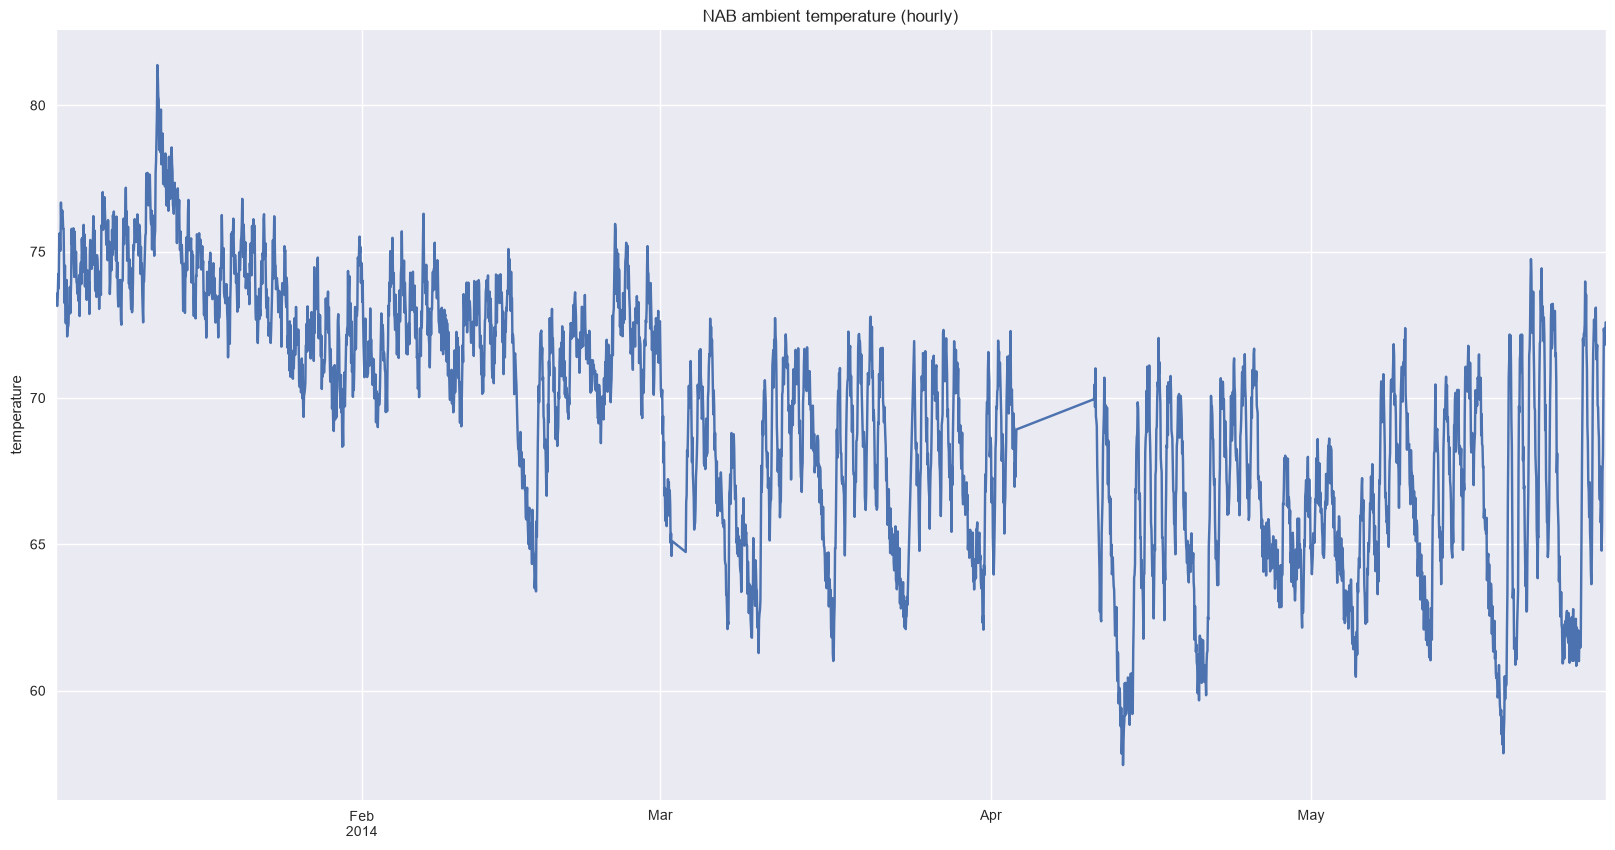

points: 3489


In [29]:
# Load the NAB ambient-temperature sensor series (hourly readings around a system failure).
temp = pd.read_csv(CFG.data_folder + "ambient_temperature_system_failure.csv")
temp["timestamp"] = pd.to_datetime(temp["timestamp"])
temp = temp.set_index("timestamp").sort_index()
temp_series = temp["value"].astype(float).asfreq("h").interpolate()   # regular hourly grid
temp_series.plot(xlabel="", title="NAB ambient temperature (hourly)")
plt.ylabel("temperature")
plt.show()
print("points:", len(temp_series))

This code loads, preprocesses, and visualizes a time series dataset representing ambient temperature readings from a sensor experiencing a system failure. The data comes from the Network Anomaly Benchmark (NAB) dataset.

First, it reads the data from a CSV file located in the directory specified by `CFG.data_folder` (which is "./data/") using `pd.read_csv()`. The filename is "ambient_temperature_system_failure.csv".

Next, it converts the “timestamp” column to datetime objects using `pd.to_datetime()`. It then sets the “timestamp” column as the index of the DataFrame using `set_index()` and sorts the DataFrame chronologically using `sort_index()`.

The code then extracts the "value" column (representing temperature readings) and converts it to a Pandas Series. The values are converted to floats using `.astype(float)`. It resamples the time series to a regular hourly frequency ("h") using `.asfreq("h")`, ensuring that there is one reading per hour. Missing values resulting from resampling are filled in using linear interpolation with `.interpolate()`.

Finally, it plots the resulting time series (`temp_series`) using `temp_series.plot()`. The plot’s x-axis label is removed, a title "NAB ambient temperature (hourly)" is added, and the y-axis is labeled “temperature”.  The plot is then displayed using `plt.show()`, providing a visual overview of the data's trend and any anomalies related to the system failure. The code also prints the total number of data points in the series to the console.

In [30]:
# Forecast-and-compare detector: rolling one-step residuals, flag large standardized errors.
WINDOW = 24 * 7          # one week of hourly history for the local seasonal-naive prediction
Z_THRESHOLD = 3.5        # standardized-residual cutoff for "anomalous"

vals = temp_series.values
resid = np.full(len(vals), np.nan)
for t in range(WINDOW, len(vals)):
    pred = vals[t - 24]                    # seasonal-naive: same hour yesterday
    resid[t] = vals[t] - pred

resid_s = pd.Series(resid, index=temp_series.index)
roll_mean = resid_s.rolling(WINDOW, min_periods=WINDOW).mean()
roll_std = resid_s.rolling(WINDOW, min_periods=WINDOW).std()
zscore = (resid_s - roll_mean) / roll_std
anomalies = zscore.abs() > Z_THRESHOLD
print(f"flagged {int(anomalies.sum())} candidate anomalies out of {len(vals)} points")

flagged 16 candidate anomalies out of 3489 points


This code implements a simple anomaly detection algorithm based on rolling one-step residuals and standardized errors. It’s designed to identify unusual temperature readings in the NAB ambient temperature dataset, potentially indicating system failures or other anomalous events.

It defines two constants: `WINDOW`, which specifies the size of the rolling window used for calculating statistics (set to 24 * 7, representing one week of hourly history), and `Z_THRESHOLD`, which sets the cutoff value for standardized residuals above which a point is considered an anomaly (set to 3.5).

The code then extracts the temperature values from the `temp_series` into a NumPy array called `vals`. It initializes an array called `resid` with the same length as `vals`, filled with NaN values, to store the residuals (the difference between actual and predicted values).

It iterates through the data starting from index `WINDOW` (to allow for sufficient history for rolling calculations). For each time step `t`, it predicts the temperature using a seasonal-naive approach: simply taking the temperature value from the same hour yesterday (`vals[t - 24]`). The residual at time `t` is calculated as the difference between the actual temperature and the predicted temperature.

The residuals are then converted into a Pandas Series called `resid_s`, with the original timestamp index from `temp_series`. Rolling mean and standard deviation are computed over a window of size `WINDOW` using `.rolling()`. The z-score (standardized residual) is calculated by subtracting the rolling mean from each residual and dividing by the rolling standard deviation.

Finally, it identifies anomalies as points where the absolute value of the z-score exceeds the `Z_THRESHOLD`. The number of flagged candidate anomalies is printed to the console. This provides a count of potentially anomalous temperature readings based on this simple anomaly detection method.

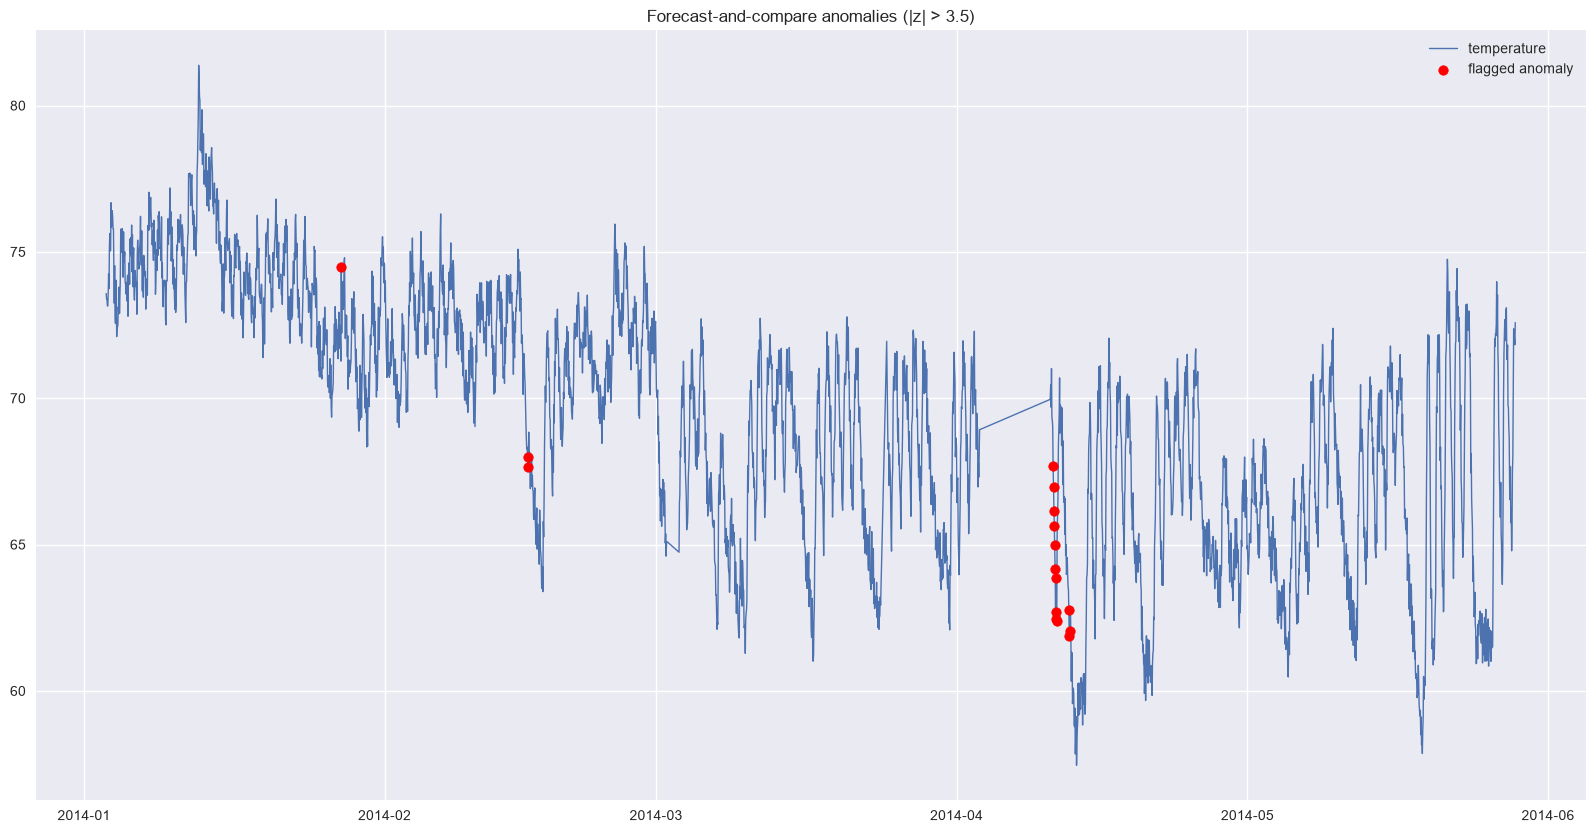

In [31]:
# Plot the series with flagged anomalies highlighted.
plt.figure()
plt.plot(temp_series.index, temp_series.values, linewidth=1, label="temperature")
plt.scatter(temp_series.index[anomalies], temp_series.values[anomalies],
            color="red", zorder=3, label="flagged anomaly")
plt.title(f"Forecast-and-compare anomalies (|z| > {Z_THRESHOLD})")
plt.xlabel(""); plt.legend(); plt.show()

This code visualizes the time series data with the detected anomalies highlighted on a plot.

It creates a new Matplotlib figure using `plt.figure()`. It plots the entire temperature time series (`temp_series`) as a line graph, with a linewidth of 1 and labeled "temperature".

Then, it identifies the indices where anomalies were flagged (using the `anomalies` boolean array from the previous step) and uses `plt.scatter()` to plot these anomalous points as red scatter points. The `zorder=3` argument ensures that the anomaly markers are drawn on top of the line graph. A label "flagged anomaly" is added for the legend.

Finally, it sets the title of the plot to indicate that the highlighted points represent anomalies with a z-score greater than the defined threshold (`Z_THRESHOLD`). The x-axis label is removed, a legend is displayed, and the plot is shown using `plt.show()`. This visualization allows for easy identification of potential anomalous temperature readings within the time series data.

In [32]:
# Summarize the top anomalies into compact evidence for the agent to reason over.
def anomaly_evidence(top_k=5):
    z = zscore.copy()
    z[~anomalies] = 0
    top_idx = z.abs().sort_values(ascending=False).index[:top_k]
    rows = []
    for ts in sorted(top_idx):
        i = temp_series.index.get_loc(ts)
        rows.append({
            "time": str(ts),
            "value": round(float(vals[i]), 2),
            "expected_same_hour_yesterday": round(float(vals[i - 24]), 2),
            "zscore": round(float(zscore.iloc[i]), 2),
        })
    return rows

evidence = anomaly_evidence()
for r in evidence:
    print(r)

{'time': '2014-04-10 23:00:00', 'value': 67.67, 'expected_same_hour_yesterday': 69.86, 'zscore': -7.16}
{'time': '2014-04-11 00:00:00', 'value': 66.98, 'expected_same_hour_yesterday': 69.87, 'zscore': -7.52}
{'time': '2014-04-11 01:00:00', 'value': 66.14, 'expected_same_hour_yesterday': 69.87, 'zscore': -7.72}
{'time': '2014-04-11 02:00:00', 'value': 65.64, 'expected_same_hour_yesterday': 69.88, 'zscore': -7.22}
{'time': '2014-04-11 05:00:00', 'value': 62.7, 'expected_same_hour_yesterday': 69.9, 'zscore': -7.2}


This code defines a function `anomaly_evidence` to summarize the top detected anomalies into a compact format suitable for an agent to reason over. It then prints this summarized evidence to the console.

The `anomaly_evidence` function takes an optional argument `top_k`, which specifies the number of top anomalies to include in the summary (defaulting to 5). Inside the function, it creates a copy of the z-score series (`zscore`) and sets all non-anomalous values to zero. This isolates the anomalous points based on their z-scores.

It then identifies the indices of the `top_k` anomalies with the highest absolute z-scores using `.abs().sort_values(ascending=False).index[:top_k]`. It iterates through these top anomaly timestamps, retrieving the corresponding index in the original time series (`temp_series`) and extracting relevant information: the timestamp itself, the actual temperature value, the expected temperature from the same hour yesterday (used for the seasonal-naive prediction), and the z-score.

This information is organized into a dictionary for each anomaly and appended to a list called `rows`. The function returns this list of dictionaries, representing the summarized evidence.

Finally, outside the function definition, it calls `anomaly_evidence()` to generate the summary and then iterates through the resulting list of dictionaries, printing each one to the console in a human-readable format. This provides a concise overview of the most significant anomalies detected in the time series data, including their context and severity (as indicated by the z-score).

In [33]:
# Agentic explanation: let the local LLM classify and explain each anomaly.
anomaly_agent = CodeAgent(tools=[], model=build_local_llm(), max_steps=4,
                          name="anomaly_explainer",
                          description="Explains flagged time-series anomalies for an operator.")

anomaly_task = (
    "You are an observability analyst reviewing flagged anomalies in an ambient-temperature sensor "
    "feed (a large deviation may indicate a cooling/system failure). For each item below, write ONE "
    "sentence: state the time, whether the reading is far above or below the expected value, and a "
    "plausible label (e.g. 'likely sensor spike', 'possible system failure', 'benign fluctuation'). "
    "Be concise and do not invent values.\n\n" + json.dumps(evidence, indent=2)
)
anomaly_explanation = anomaly_agent.run(anomaly_task) if LLM_UP else \
    "\n".join(f"- {e['time']}: reading {e['value']} vs expected {e['expected_same_hour_yesterday']} (z={e['zscore']}) — review." for e in evidence)
print("ANOMALY EXPLANATIONS:\n", anomaly_explanation)

ANOMALY EXPLANATIONS:
 - 2014-04-10 23:00:00: reading 67.67 vs expected 69.86 (z=-7.16) — review.
- 2014-04-11 00:00:00: reading 66.98 vs expected 69.87 (z=-7.52) — review.
- 2014-04-11 01:00:00: reading 66.14 vs expected 69.87 (z=-7.72) — review.
- 2014-04-11 02:00:00: reading 65.64 vs expected 69.88 (z=-7.22) — review.
- 2014-04-11 05:00:00: reading 62.7 vs expected 69.9 (z=-7.2) — review.


This code defines an agent, named “anomaly\_explainer,” whose role is to classify and explain the detected anomalies using a local Large Language Model (LLM).

It creates an instance of the `CodeAgent` class, configuring it with:

*   `tools`: An empty list because this agent doesn’t need to call any external tools; it relies solely on its reasoning capabilities and the provided evidence.
*   `model`: The local LLM created by calling `build_local_llm()`.
*   `max_steps`: Set to 4 to limit the number of reasoning steps.
*   `name`: Assigned the name "anomaly\_explainer" for identification purposes.
*   `description`: A descriptive string explaining the agent’s role: “Explains flagged time-series anomalies for an operator.”

A task description (`anomaly_task`) is defined, instructing the agent to act as an observability analyst and review the flagged anomalies in the ambient temperature sensor feed. The agent is asked to write one sentence for each anomaly item, stating the time, whether the reading is significantly above or below the expected value, and a plausible label (e.g., "likely sensor spike," "possible system failure," "benign fluctuation"). It emphasizes conciseness and avoiding invention of values.

The evidence list generated in the previous step (`evidence`) is converted into a JSON string using `json.dumps(evidence, indent=2)` and appended to the task description. This provides the agent with structured information about each anomaly.

The code then runs the agent using `anomaly_agent.run(anomaly_task)`. As before, it includes a conditional check: if `LLM_UP` is `False`, it generates a default explanation for each anomaly by simply stating the time, reading, expected value, and z-score, prompting manual review.

Finally, the code prints the agent’s generated explanations (`anomaly_explanation`) to the console. This provides human-readable interpretations of the detected anomalies, helping an operator quickly assess their potential significance and take appropriate action.

# Head-to-head / takeaways

In [34]:
summary_rows = [
    {"approach": "Baseline (best of 4)", "topology": "none", "model": best_name,
     "RMSE": baseline_table.iloc[0]["RMSE"], "explains?": "no"},
    {"approach": "Rung 0: direct LLM",   "topology": "direct", "model": "LLM numeric",
     "RMSE": round(float(np.sqrt(mean_squared_error(test.values, direct_fc))), 2) if len(direct_fc)==CFG.HORIZON else np.nan,
     "explains?": "no"},
    {"approach": "Rung 1: single agent", "topology": "linear chain", "model": rung1_choice,
     "RMSE": rung1_scores["RMSE"], "explains?": "choice"},
    {"approach": "Rung 2: diagnostics agent", "topology": "linear chain", "model": rung2_choice,
     "RMSE": rung2_scores["RMSE"], "explains?": "evidence log"},
    {"approach": "Rung 3: multi-agent", "topology": "branch", "model": chosen,
     "RMSE": final_scores["RMSE"], "explains?": "full report"},
]
summary = pd.DataFrame(summary_rows)
summary

,approach,topology,model,RMSE,explains?
0,Baseline (best of 4),none,chronos2,17.92,no
1,Rung 0: direct LLM,direct,LLM numeric,21.22,no
2,Rung 1: single agent,linear chain,chronos2,17.92,choice
3,Rung 2: diagnostics agent,linear chain,chronos2,17.92,evidence log
4,Rung 3: multi-agent,branch,chronos2,17.92,full report
